In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import itertools
rng = np.random.default_rng(seed=None)

In [4]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=5,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [5]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs
wavelength = df['Wavelength']

# this array serves as the 'basis function' for the NNLS 
abs_spectra = df.iloc[:, 1:].to_numpy().T # (n_wavelengths, n_species)

mixture, weights = generate_mixture_spectra(df, combination_sizes=(7, 8,9), n_mixtures_per_combination=100)
mixture, weights = mixture.to_numpy(), weights.to_numpy()
# need to cut out pure spectra and wavelength columns
mixture, weights = mixture[:,10:], weights[:,1:]

(451, 4600)
(451, 9)
(4600, 9)


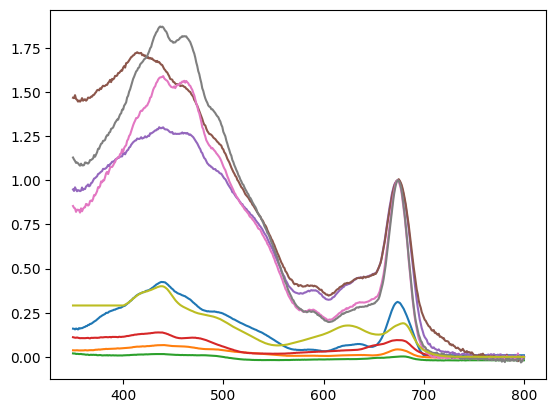

In [ ]:
print(mixture.shape)
print(abs_spectra.T.shape)
print(weights.shape)


In [7]:
noise = rng.normal(0, 1, size = mixture.shape)
# add 10% noise
mixture_noisy = mixture + 0.1 * noise

In [8]:
# NNLS - scipy algorithm
estimated_conc = np.array([nnls(abs_spectra.T, mixture_noisy[:, i])[0] for i in range(mixture_noisy.shape[1])])

In [9]:
# transfer into floats
estimated_conc = np.array(estimated_conc, dtype=float)
weights = np.array(weights, dtype=float)
difference = np.abs(estimated_conc - weights)

# find the mean and std of difference per mixture
mean_accuracy_per_mixture = np.mean(difference, axis =1)
std_accuracy_per_mixture = np.std(difference, axis = 1)

0.9574924267907154


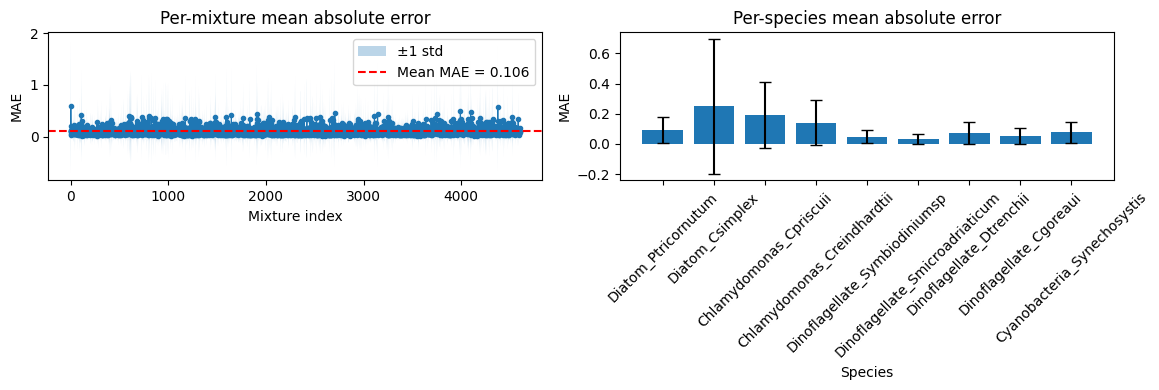

In [10]:
# plot for clarity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mean_accuracy_per_mixture, marker='o', markersize=3, linewidth=0.8)
axes[0].fill_between(
    range(len(mean_accuracy_per_mixture)),
    mean_accuracy_per_mixture - std_accuracy_per_mixture,
    mean_accuracy_per_mixture + std_accuracy_per_mixture,
    alpha=0.3, label='±1 std'
)
axes[0].axhline(np.mean(mean_accuracy_per_mixture), color='red', linestyle='--', label=f'Mean MAE = {np.mean(mean_accuracy_per_mixture):.3f}')
axes[0].set_xlabel("Mixture index")
axes[0].set_ylabel("MAE")
axes[0].set_title("Per-mixture mean absolute error")
axes[0].legend()


species_names = df.columns[1:].tolist()

# mean and std of difference per specie (most insightful)
per_species_mae = np.mean(difference, axis=0)
per_species_std = np.std(difference, axis=0)
# sums up to 1?
print(np.sum(per_species_mae))

axes[1].bar(species_names, per_species_mae, yerr=per_species_std, capsize=4)
axes[1].set_xlabel("Species")
axes[1].set_ylabel("MAE")
axes[1].set_title("Per-species mean absolute error")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# for scattering, just add a Mie scattering spectra as a 'pure' spectra. 
# The NNLS will then just use this to estimate the scattering

In [ ]:


epsilon = 78.75*1e5  # extinction coefficient of Chl a [l/(mol*m)]
l = 1e-2            # cuvette path length, assumed to be standard 1 cm


abs_row = df.loc[df["Wavelength"].eq(662)].squeeze() 

abs_Chla = abs_row.drop(labels=["Wavelength"], errors="ignore") # absorbance of each strain at 662 nm-Chl a peak


# Chl a per cell, moles/cell (molecular weight Chla: 893.509 g / mol)
# tied to strain/column names so that the calculation is a bit more robust, against re-arrangement of the columns in this case
# ideally, Chl a per cell per strain (environment-dependent) would be saved along with the non-mixed absorption spectra

Chla_cell = pd.Series(
    {
        "Diatom_Ptricornutum": 0.3,
        "Diatom_Csimplex": 1.285,
        "Chlamydomonas_Cpriscuii": 2.17,
        "Chlamydomonas_Creindhardtii": 2.2,
        "Dinoflagellate_Symbiodiniumsp": 7,
        "Dinoflagellate_Smicroadriaticum": 16,
        "Dinoflagellate_Dtrenchii": 6,
        "Dinoflagellate_Cgoreaui": 7.25,
        "Cyanobacteria_Synechosystis": 0.008,
    },
    dtype=float,
) * 1e-12 * (893.509)**(-1)

# name match check
missing_in_df = Chla_cell.index.difference(abs_Chla.index)
missing_in_chla = abs_Chla.index.difference(Chla_cell.index)

if len(missing_in_df) or len(missing_in_chla):
    raise ValueError(
        f"Name mismatch.\n"
        f"In Chla_cell but not df: {list(missing_in_df)}\n"
        f"In df but not Chla_cell: {list(missing_in_chla)}"
    )

# finally align by strain name, redundant here, but important if column order is changed compared to our original table
abs_Chla = abs_Chla[Chla_cell.index]


# concentration of Chl a from Beer-Lambert law
c_Chla = abs_Chla / (epsilon * l)

# actual strain cells per volume
cells_per_volume = c_Chla / Chla_cell

results = pd.DataFrame({
    "Absorbance at 662 nm": abs_Chla,
    "Chla per cell in kg": Chla_cell,
    "Chla concentration": c_Chla,
    "Estimated cells per litre": cells_per_volume*1e3,
})
print("\n=== Strain concentrations ===\n")
print(results)


=== Strain concentrations ===

                                 Absorbance at 662 nm  Chla per cell in kg  \
Diatom_Ptricornutum                           0.15986         3.357549e-16   
Diatom_Csimplex                               0.02101         1.438150e-15   
Chlamydomonas_Cpriscuii                      -0.00432         2.428627e-15   
Chlamydomonas_Creindhardtii                   0.07806         2.462202e-15   
Dinoflagellate_Symbiodiniumsp                 0.69565         7.834280e-15   
Dinoflagellate_Smicroadriaticum               0.68564         1.790693e-14   
Dinoflagellate_Dtrenchii                      0.55064         6.715097e-15   
Dinoflagellate_Cgoreaui                       0.51752         8.114076e-15   
Cyanobacteria_Synechosystis                   0.13616         8.953463e-18   

                                 Chla concentration  \
Diatom_Ptricornutum                    2.029968e-06   
Diatom_Csimplex                        2.667937e-07   
Chlamydomonas_Cpriscui